# **Loading The Data**

In [1]:
import os
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import numpy as np
import shutil
from glob import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, Model
from sklearn.model_selection import StratifiedKFold
from skimage import exposure
import pickle
import random
import sys
import gc

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
base_dir = "/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή"

In [4]:
sys.path.append('/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή')
from PreProcessing_Script import dataset_preparation, Model

In [5]:
effnet_ft_root_dir = "/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/EfficientNetB0 fine-tuning Model"

def create_experiment_folders(experiment_name):
    experiment_dir = os.path.join(effnet_ft_root_dir, experiment_name)
    results_dir = os.path.join(experiment_dir, "results")
    images_dir = os.path.join(results_dir, "images")
    models_dir = os.path.join(results_dir, "models")
    report_dir = os.path.join(results_dir, "report")

    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(models_dir, exist_ok=True)
    os.makedirs(report_dir, exist_ok=True)

    return {
        "experiment_dir": experiment_dir,
        "results_dir": results_dir,
        "images_dir": images_dir,
        "models_dir": models_dir,
        "report_dir": report_dir
    }

combined_roc_effnet_finetuning_path = os.path.join(effnet_ft_root_dir, "combined_roc_effnet_finetuning.png")
effnet_experiments_finetuning_path  = os.path.join(effnet_ft_root_dir, "effnet_finetuning_experiments.pkl")

In [6]:
K = 5
EPOCHS = 30
BATCH_SIZE = 32
LR = 1e-4
Class_Names = ["Glioma", "Meningioma", "Pituitary"]
all_experiments = {}
input_shape = (224, 224, 3)

In [7]:
x_train_val_raw = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/x_train_val_raw.pkl","rb"))
x_test_raw      = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/x_test_raw.pkl","rb"))
y_train_val_int = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/y_train_val_int.pkl","rb"))
y_test_int      = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/y_test_int.pkl","rb"))

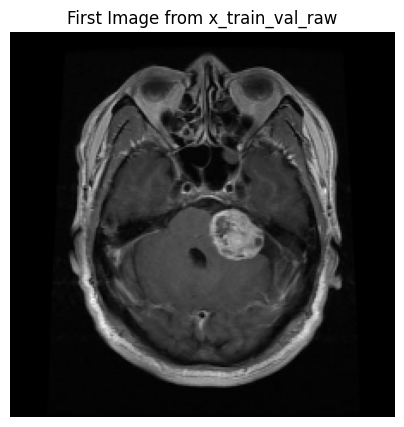

In [8]:
# Select the first image from x_train_val_raw
# Assuming x_train_val_raw is a NumPy array of images
image_to_display = x_train_val_raw[0]

plt.figure(figsize=(5, 5))
plt.imshow(image_to_display, cmap='gray')
plt.title('First Image from x_train_val_raw')
plt.axis('off') # Hide axes ticks and labels
plt.show()

# Saving

In [9]:
def get_save_paths(model_or_experiment_name):
    if isinstance(model_or_experiment_name, str):
        experiment_name = model_or_experiment_name
    else:
        experiment_name = model_or_experiment_name.experiment_name

    folders = create_experiment_folders(experiment_name)

    paths = {
        "model": os.path.join(folders["models_dir"], f"{experiment_name}.keras"),
        "train_loss": os.path.join(folders["images_dir"], f"{experiment_name}_train_loss.png"),
        "train_accuracy": os.path.join(folders["images_dir"], f"{experiment_name}_train_accuracy.png"),
        "confusion_matrix": os.path.join(folders["images_dir"], f"{experiment_name}_confusion_matrix.png"),
        "roc_curve": os.path.join(folders["images_dir"], f"{experiment_name}_roc_curve.png"),
        "auc_report": os.path.join(folders["report_dir"], f"{experiment_name}_auc_report.txt"),
        "classification_report": os.path.join(folders["report_dir"], f"{experiment_name}_classification_report.txt"),
        "confusion_matrix_txt": os.path.join(folders["report_dir"], f"{experiment_name}_confusion_matrix.txt"),
        "kfold_metrics": os.path.join(folders["report_dir"], f"{experiment_name}_kfold_metrics.txt"),
        "kfold_loss": os.path.join(folders["images_dir"], f"{experiment_name}_kfold_loss.png"),
        "kfold_accuracy": os.path.join(folders["images_dir"], f"{experiment_name}_kfold_accuracy.png"),
        "roc_raw_data": os.path.join(folders["report_dir"], f"{experiment_name}_roc_raw_data")
    }

    return paths

# Plots

In [10]:
def acc_and_loss(history, model_experiment_name, save_paths=None):
  hist = history.history

  epochs_acc = np.arange(1, len(hist["accuracy"])+1)
  epochs_loss = np.arange(1, len(hist["loss"])+1)

  fig_acc, ax_acc = plt.subplots(figsize=(10,5), dpi = 120)
  ax_acc.plot(
      epochs_acc,
      hist["accuracy"],
      label = "Training Accuracy",
      linewidth = 2,
      marker = 'o',
      markersize = 5
  )

  if "val_accuracy" in hist:
    ax_acc.plot(
        epochs_acc,
        hist["val_accuracy"],
        label = "Validation Accuracy",
        linewidth = 2,
        marker = 's',
        markersize = 5
    )

  ax_acc.set_title(f"{model_experiment_name} - Accuracy")
  ax_acc.set_xlabel("Epoch")
  ax_acc.set_ylabel("Accuracy")
  ax_acc.legend()
  ax_acc.grid(alpha=0.3)

  if save_paths is not None:
    fig_acc.savefig(save_paths["train_accuracy"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_acc)

  fig_loss, ax_loss = plt.subplots(figsize=(10,5), dpi = 120)
  ax_loss.plot(
      epochs_loss,
      hist["loss"],
      label = "Training Loss",
      linewidth = 2,
      marker = 'o',
      markersize = 5
  )

  if "val_loss" in hist:
    ax_loss.plot(
        epochs_loss,
        hist["val_loss"],
        label = "Validation Loss",
        linewidth = 2,
        marker = 's',
        markersize = 5
    )

  ax_loss.set_title(f"{model_experiment_name} - Loss")
  ax_loss.set_xlabel("Epoch")
  ax_loss.set_ylabel("Loss")
  ax_loss.legend()
  ax_loss.grid(alpha=0.3)

  if save_paths is not None:
    fig_loss.savefig(save_paths["train_loss"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_loss)

  print('Loss:')
  print('  - loss [training dataset]: {:.3f}'.format(hist['loss'][-1]))
  if 'val_loss' in hist:
    print('  - loss [validation dataset]: {:.3f}'.format(hist['val_loss'][-1]))

  print('')
  print('Accuracy:')
  print('  - accuracy [training dataset]: {:.2f}%'.format(hist['accuracy'][-1] * 100))
  if 'val_accuracy' in hist:
    print('  - accuracy [validation dataset]: {:.2f}%'.format(hist['val_accuracy'][-1] * 100))

  return fig_acc, fig_loss

In [11]:
def plot_kfold(histories, title_prefix='', save_paths = None):

  min_len = min([len(h['loss']) for h in histories])

  train_loss = np.array([h['loss'][:min_len] for h in histories])
  val_loss = np.array([h['val_loss'][:min_len] for h in histories])

  train_acc = np.array([h['accuracy'][:min_len] for h in histories])
  val_acc = np.array([h['val_accuracy'][:min_len] for h in histories])

  epochs = np.arange(1, min_len+1)

  # Loss plot
  fig_loss, ax_loss = plt.subplots(figsize=(10, 5), dpi=120)
  ax_loss.plot(epochs, train_loss.mean(axis=0), label='Training Loss')
  ax_loss.plot(epochs, val_loss.mean(axis=0), label='Validation Loss')
  ax_loss.set_title(f'{title_prefix} - KFold Loss')
  ax_loss.set_xlabel('Epochs')
  ax_loss.set_ylabel('Loss')
  ax_loss.legend()
  ax_loss.grid(True, alpha=0.3)
  fig_loss.tight_layout()

  if save_paths is not None and "kfold_loss" in save_paths:
    fig_loss.savefig(save_paths["kfold_loss"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_loss)

  # Accuracy plot
  fig_acc, ax_acc = plt.subplots(figsize=(10, 5), dpi=120)
  ax_acc.plot(epochs, train_acc.mean(axis=0), label='Training Accuracy')
  ax_acc.plot(epochs, val_acc.mean(axis=0), label='Validation Accuracy')
  ax_acc.set_title(f'{title_prefix} - KFold Accuracy')
  ax_acc.set_xlabel('Epochs')
  ax_acc.set_ylabel('Accuracy')
  ax_acc.legend()
  ax_acc.grid(True, alpha=0.3)
  fig_acc.tight_layout()

  if save_paths is not None and "kfold_accuracy" in save_paths:
    fig_acc.savefig(save_paths["kfold_accuracy"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_acc)

In [12]:
def plot_confusion_matrix(cm, Class_Names, save_path=None):

  plt.figure()
  plt.colorbar(plt.imshow(cm))
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.xticks(np.arange(len(Class_Names)), Class_Names, rotation=45)
  plt.yticks(np.arange(len(Class_Names)), Class_Names)

  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
      plt.text(j, i, str(cm[i, j]), ha="center", va="center")

  plt.tight_layout()

  if save_path is not None:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

  plt.show()

In [13]:
def plot_roc_auc(y_true_int, y_prob, class_names, save_path=None):
  n_classes = len(class_names)

  y_true_bin = label_binarize(y_true_int, classes=np.arange(n_classes))

  fpr = dict()
  tpr = dict()
  roc_auc = dict()

  plt.figure(figsize=(10, 10), dpi=120)

  for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

  plt.plot([0,1], [0,1], 'k--', linewidth=1)

  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve (One-vs-Rest)")
  plt.legend(loc="lower right")
  plt.grid(alpha=0.3)
  plt.tight_layout()

  if save_path is not None:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

  plt.show()

  macro_auc = np.mean(list(roc_auc.values()))
  print("\nAUC per Class: ")
  for i in range(n_classes):
    print(f"{class_names[i]}: {roc_auc[i]:.4f}")
  print(f"Macro AUC: {macro_auc:.4f}")

  return roc_auc, macro_auc

In [14]:
def plot_combined_roc(experiments, class_names, save_path=None):
    n_classes = len(class_names)

    plt.figure(figsize=(10, 10), dpi=120)

    for exp_name, exp_data in experiments.items():
        data = np.load(exp_data["roc_raw_data"])

        all_fpr  = np.linspace(0, 1, 100)
        mean_tpr = np.zeros_like(all_fpr)

        for i in range(n_classes):
            fpr = data[f"fpr_{i}"]
            tpr = data[f"tpr_{i}"]
            mean_tpr += np.interp(all_fpr, fpr, tpr)

        mean_tpr /= n_classes
        macro_auc = exp_data["macro_auc"]

        plt.plot(all_fpr, mean_tpr, linewidth=2,
                 label=f"{exp_name} (Macro AUC = {macro_auc:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison (Macro Average)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

# Compile Function

In [15]:
def compile_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=["accuracy"]
    )
    return model

# EfficientNetB0 Fine - Tuning Models

## Base Model

In [16]:
def effnetb0_finetune_model(use_augmentation=False, model_key="effnetb0_finetune", unfreeze_from = -20):

  base_model = EfficientNetB0(
      weights = "imagenet",
      include_top = False,
      input_shape = (224,224,3)
  )

  base_model.trainable = True

  for layer in base_model.layers[:unfreeze_from]:
    layer.trainable = False

  for layer in base_model.layers[unfreeze_from:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
      layer.trainable = False

  inputs = layers.Input(shape=(224,224,3))
  x = inputs

  if use_augmentation:
    augmentation = build_augmentation()
    x = augmentation(x)

  x = base_model(x, training=False)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dropout(0.2)(x)
  outputs = layers.Dense(3, activation="softmax")(x)

  model = tf.keras.Model(inputs = inputs, outputs = outputs, name=model_key)

  model.model_key = model_key
  model.experiment_name = model_key

  return model

In [17]:
model_effnetb0_finetune = effnetb0_finetune_model()
model_effnetb0_finetune.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "effnetb0_finetune"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 1,346,611 (5.14 MB)

 Non-trainable params: 2,706,803 (10.33 MB)

## Data Augmentation

In [18]:
def build_augmentation():
  return tf.keras.Sequential([
      layers.RandomRotation(0.01),
      layers.RandomTranslation(0.005, 0.005),
      layers.RandomZoom(0.01)
  ], name="data_augmentation")

# Builder

In [19]:
def build_model(cfg):
  model = cfg["builder"]()
  model.model_key = cfg["model_key"]
  model.experiment_name = cfg["experiment_name"]
  return model

# List Of Experiments

In [20]:
EXPERIMENTS = {
    "effnetb0_finetune": {
        "builder": lambda: effnetb0_finetune_model(
            use_augmentation=False,
            model_key="effnetb0_finetune",
            unfreeze_from=-20
        ),
        "model_key": "effnetb0_finetune",
        "experiment_name": "effnetb0_finetune",
        "use_augmentation": False
    },
    "effnetb0_finetune_aug": {
        "builder": lambda: effnetb0_finetune_model(
            use_augmentation=True,
            model_key="effnetb0_finetune_aug",
            unfreeze_from=-20
        ),
        "model_key": "effnetb0_finetune_aug",
        "experiment_name": "effnetb0_finetune_aug",
        "use_augmentation": True
    }
}

# Dataset Preperation

In [21]:
def make_ds(X, y, batch_size=32, training=False, augmentation=None):
    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if training:
      ds = ds.shuffle(len(X), seed=42, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size)

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [22]:
def get_preprocessed_data(cfg, x_train_val_raw, x_test_raw):
    model_key = cfg["model_key"]
    preprocess_name = Model[model_key]["preprocess"]

    print(f"Preprocessing for: {preprocess_name}")

    x_train_val_pp, x_test_pp = dataset_preparation(
        model_key,
        x_train_val_raw,
        x_test_raw
    )

    return x_train_val_pp, x_test_pp

# Functions for K-Fold, Training and Evaluation

In [23]:
def kfold(x_raw, y, cfg, K, BATCH_SIZE, LR, EPOCHS):
  skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

  fold_metrics = []
  fold_histories = []

  for fold, (train_idx, val_idx) in enumerate(skf.split(x_raw, y), start=1):
    print(f"\n=== {cfg['experiment_name']} / Fold {fold}/{K} ===")

    x_tr_raw = x_raw[train_idx]
    x_va_raw = x_raw[val_idx]
    y_tr = y[train_idx]
    y_va = y[val_idx]

    x_tr, x_va = get_preprocessed_data(cfg, x_tr_raw, x_va_raw)

    train_ds = make_ds(x_tr, y_tr, BATCH_SIZE, training=True)
    val_ds = make_ds(x_va, y_va, BATCH_SIZE, training=False)

    model = build_model(cfg)
    model = compile_model(model, lr=LR)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            min_delta=0.001)
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=callbacks
    )

    val_loss, val_acc = model.evaluate(val_ds, verbose=0)

    fold_metrics.append({
        "fold": fold,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    fold_histories.append({
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"]
    })

    del x_tr, x_va, y_tr, y_va, train_idx, val_idx, train_ds, val_ds, model, history, x_tr_raw, x_va_raw
    gc.collect()
    tf.keras.backend.clear_session()

  return fold_metrics, fold_histories

In [24]:
def train_test(cfg, x_train_val_raw, y_train_val_int, x_test_raw, y_test_int, save_model=True):

  model = build_model(cfg)
  save_paths = get_save_paths(model)

  x_train_raw, x_val_raw, y_train_int, y_val_int = train_test_split(
      x_train_val_raw,
      y_train_val_int,
      test_size=0.2,
      random_state=42,
      stratify=y_train_val_int
  )

  x_train_pp, x_val_pp = get_preprocessed_data(cfg, x_train_raw, x_val_raw)
  _, x_test_pp = get_preprocessed_data(cfg, x_train_val_raw[:1], x_test_raw)


  train_ds = make_ds(x_train_pp, y_train_int, BATCH_SIZE, training=True)
  val_ds = make_ds(x_val_pp, y_val_int, BATCH_SIZE, training=False)
  test_ds = make_ds(x_test_pp, y_test_int, BATCH_SIZE, training=False)

  model = compile_model(model, lr=LR)

  callbacks = [
      tf.keras.callbacks.EarlyStopping(
          monitor='val_accuracy',
          patience=5,
          restore_best_weights=True,
          min_delta=0.001)
  ]

  history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=EPOCHS,
      verbose=1,
      callbacks=callbacks
  )

  if save_model:
    model.save(save_paths["model"])

  test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

  y_prob = model.predict(test_ds, verbose=0)
  y_pred = np.argmax(y_prob, axis=1)

  cm = confusion_matrix(y_test_int, y_pred)

  print("Test Loss: ", float(test_loss))
  print("Test Accuracy: ", float(test_accuracy))

  report = classification_report(
      y_test_int,
      y_pred,
      target_names=Class_Names
  )

  print("Classification Report:")
  print(report)

  roc_auc_dict, macro_auc = plot_roc_auc(
      y_test_int,
      y_prob,
      Class_Names,
      save_paths["roc_curve"]
  )

  y_true_bin = label_binarize(y_test_int, classes=np.arange(len(Class_Names)))
  save_dict = {}
  for i in range(len(Class_Names)):
    fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    save_dict[f"fpr_{i}"] = fpr_i
    save_dict[f"tpr_{i}"] = tpr_i
  np.savez(save_paths["roc_raw_data"], **save_dict)

  with open(save_paths["classification_report"], "w") as f:
    f.write(report)
    f.write("\n")
    f.write(f"Test Loss: {float(test_loss):.4f}\n")
    f.write(f"Test Accuracy: {float(test_accuracy):.4f}\n")
    f.write(f"Macro AUC: {macro_auc:.4f}\n")

  with open(save_paths["confusion_matrix_txt"], "w") as f:
    f.write(str(cm))

  with open(save_paths["auc_report"], "w") as f:
    for i, class_name in enumerate(Class_Names):
      f.write(f"{class_name}: AUC = {roc_auc_dict[i]:.4f}\n")
    f.write(f"Macro AUC: {macro_auc:.4f}\n")

  plot_confusion_matrix(cm, Class_Names, save_paths["confusion_matrix"])
  acc_and_loss(history, model.experiment_name, save_paths=save_paths)

  del x_train_pp, x_val_pp, x_test_pp, train_ds, val_ds, test_ds
  gc.collect()

  return model, history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, save_paths["roc_raw_data"]

# Base EfficientNetB0 Fine - Tuning Model

In [25]:
cfg_effnet_ft = EXPERIMENTS["effnetb0_finetune"]

## K-Fold(K = 5)

In [26]:
effnet_ft_metrics, effnet_ft_histories = kfold(
    x_raw=x_train_val_raw,
    y=y_train_val_int,
    cfg=cfg_effnet_ft,
    K=K,
    BATCH_SIZE=BATCH_SIZE,
    LR=LR,
    EPOCHS=EPOCHS
)


=== effnetb0_finetune / Fold 1/5 ===
Preprocessing for: effnet
Using preprocessing: effnet
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 80s 708ms/step - accuracy: 0.7107 - loss: 0.6772 - val_accuracy: 0.8473 - val_loss: 0.4088
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.8500 - loss: 0.3649 - val_accuracy: 0.8758 - val_loss: 0.3383
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.8811 - loss: 0.2823 - val_accuracy: 0.8859 - val_loss: 0.2893
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9077 - loss: 0.2328 - val_accuracy: 0.8900 - val_loss: 0.2866
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9138 - loss: 0.2102 - val_accuracy: 0.8941 - val_loss: 0.2642
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9372 - loss: 0.1726 - val_accuracy: 0.9165 - val_loss: 0.2377
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9398 - loss: 0.1519 - val_accuracy: 0.9084 - val_loss: 0.2449
Epoch 8/30
62/62 

In [27]:
effnet_base_accuracy = [m["val_acc"] for m in effnet_ft_metrics]
effnet_base_losses = [m["val_loss"] for m in effnet_ft_metrics]

print("Fold Accuracies:", effnet_base_accuracy)
print("Mean Accuracy :", np.mean(effnet_base_accuracy))
print("Std Accuracy  :", np.std(effnet_base_accuracy))
print("Mean Loss     :", np.mean(effnet_base_losses))
print("Std Loss      :", np.std(effnet_base_losses))

Fold Accuracies: [0.9389002323150635, 0.9285714030265808, 0.9489796161651611, 0.9346938729286194, 0.9571428298950195]
Mean Accuracy : 0.9416575908660889
Std Accuracy  : 0.010205384736753509
Mean Loss     : 0.17595134973526
Std Loss      : 0.029478233822283997


In [28]:
save_paths = get_save_paths(cfg_effnet_ft["experiment_name"])

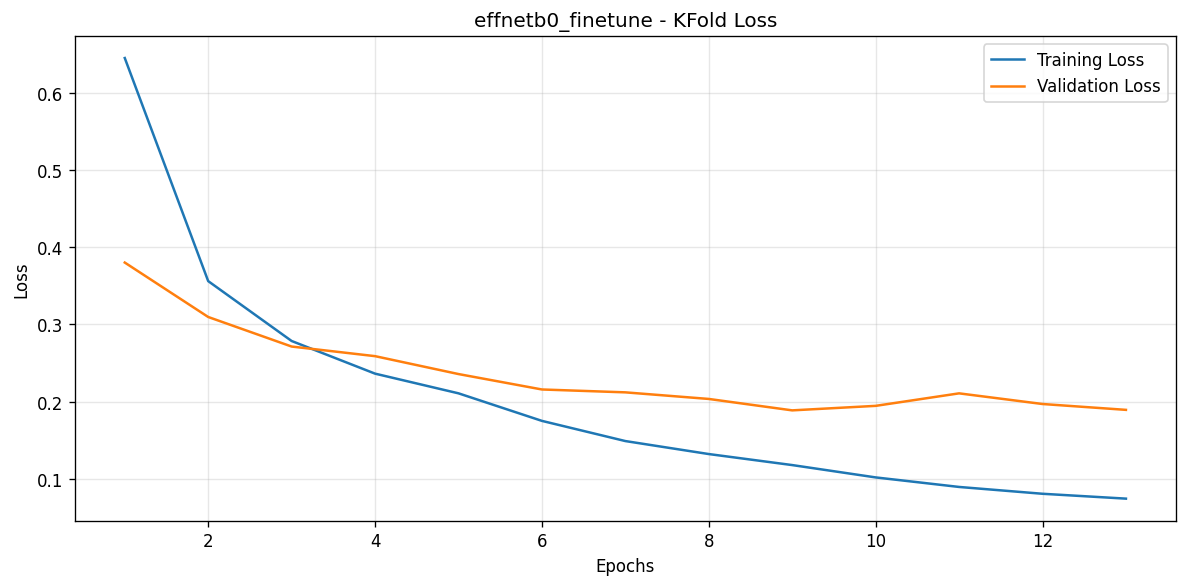

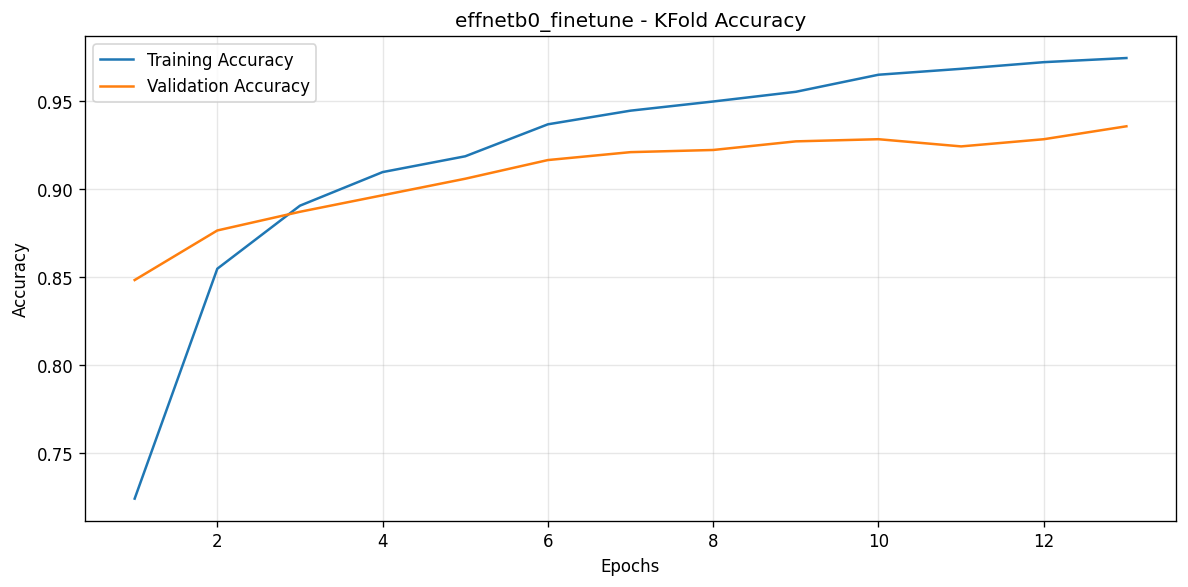

In [29]:
plot_kfold(
    effnet_ft_histories,
    title_prefix=cfg_effnet_ft["experiment_name"],
    save_paths=save_paths
)

In [30]:
with open(save_paths["kfold_metrics"], "w") as f:
    for row in effnet_ft_metrics:
        f.write(f"Fold {row['fold']}: val_acc={row['val_acc']:.4f}, val_loss={row['val_loss']:.4f}\n")

    f.write("\n")
    f.write(f"Mean val_acc: {np.mean(effnet_base_accuracy):.4f}\n")
    f.write(f"Std val_acc : {np.std(effnet_base_accuracy):.4f}\n")
    f.write(f"Mean val_loss: {np.mean(effnet_base_losses):.4f}\n")
    f.write(f"Std val_loss : {np.std(effnet_base_losses):.4f}\n")

In [31]:
del effnet_ft_metrics
del effnet_ft_histories
gc.collect()

38577

In [32]:
tf.keras.backend.clear_session()

## Training + Evaluation

Preprocessing for: effnet
Using preprocessing: effnet
Preprocessing for: effnet
Using preprocessing: effnet
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 53s 498ms/step - accuracy: 0.7536 - loss: 0.6009 - val_accuracy: 0.8554 - val_loss: 0.3703
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.8587 - loss: 0.3513 - val_accuracy: 0.8798 - val_loss: 0.3040
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.8842 - loss: 0.2959 - val_accuracy: 0.8900 - val_loss: 0.2552
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9122 - loss: 0.2306 - val_accuracy: 0.8921 - val_loss: 0.2385
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.9265 - loss: 0.2014 - val_accuracy: 0.9226 - val_loss: 0.2005
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9255 - loss: 0.1828 - val_accuracy: 0.9165 - val_loss: 0.1969
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9449 - loss: 0.1593 - val_accuracy: 0.9308 - val_loss: 0.1891


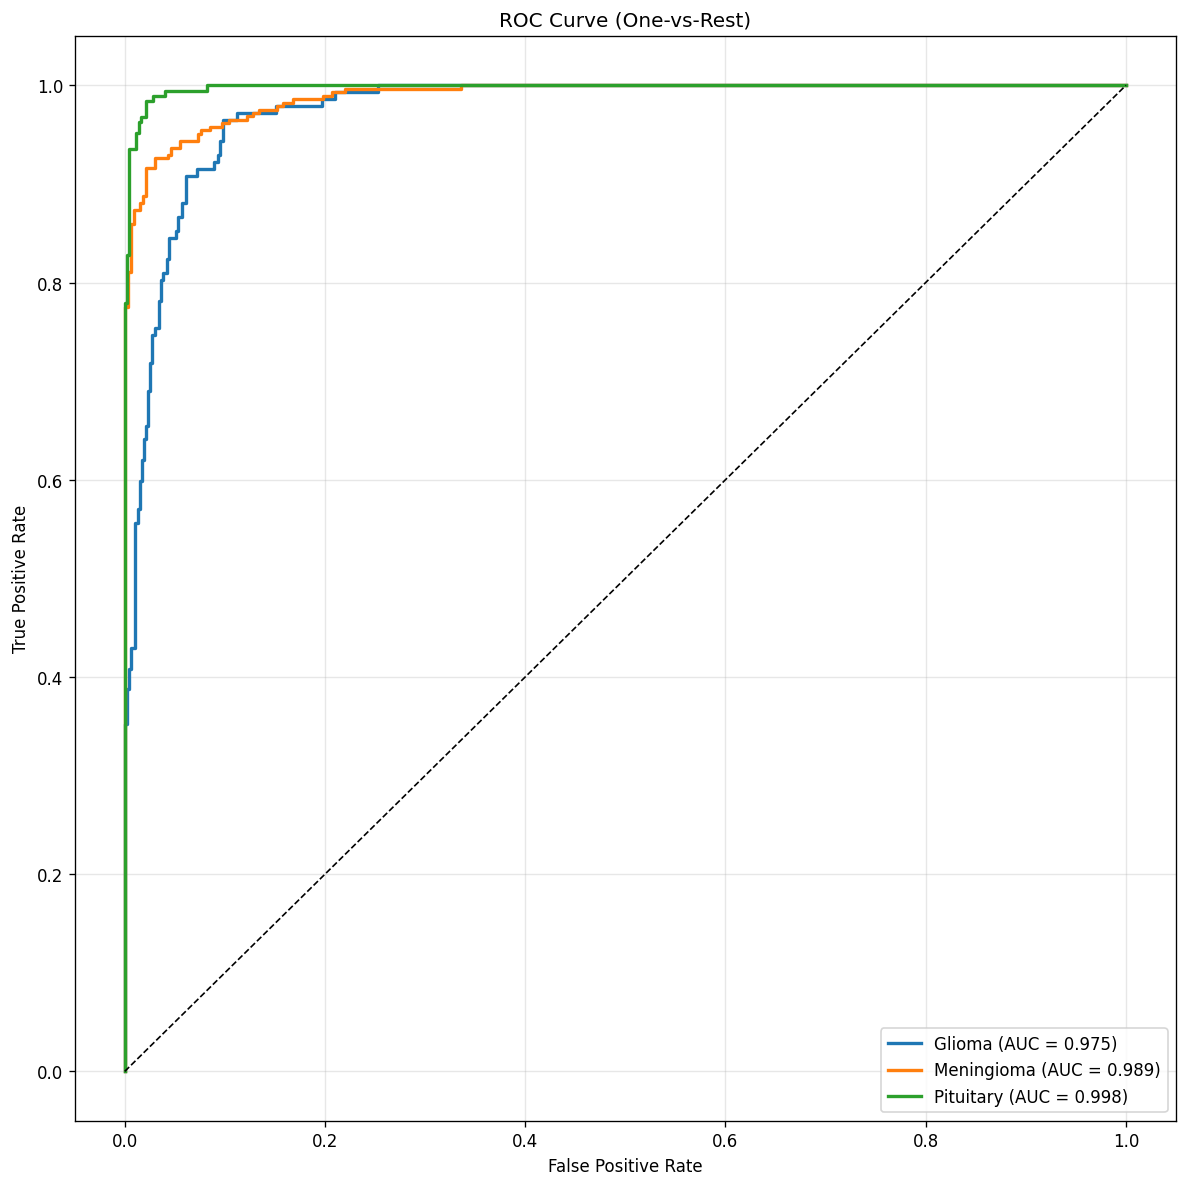


AUC per Class: 
Glioma: 0.9753
Meningioma: 0.9893
Pituitary: 0.9978
Macro AUC: 0.9875


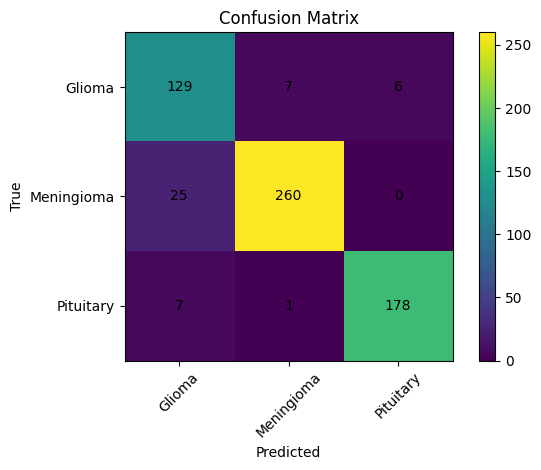

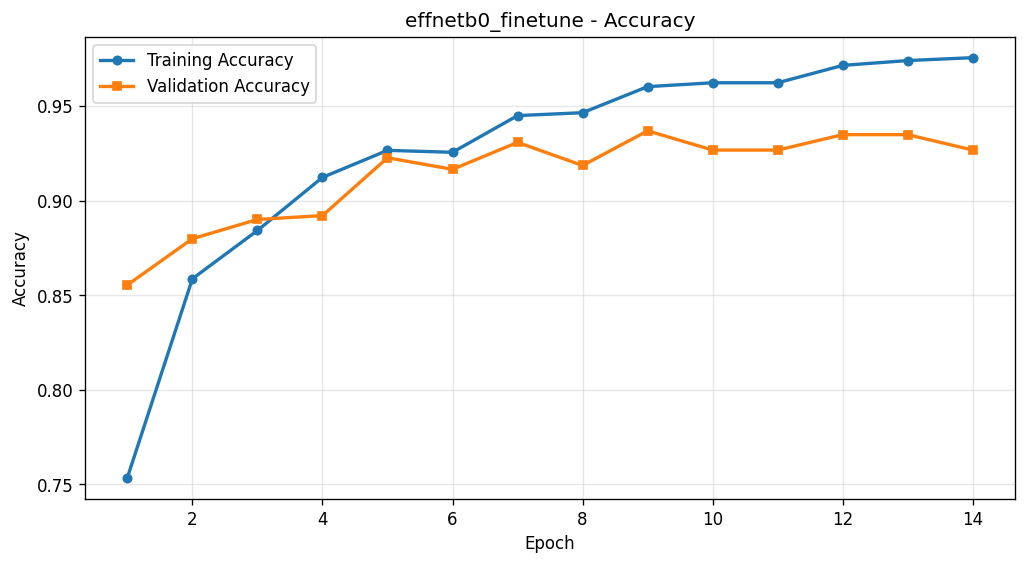

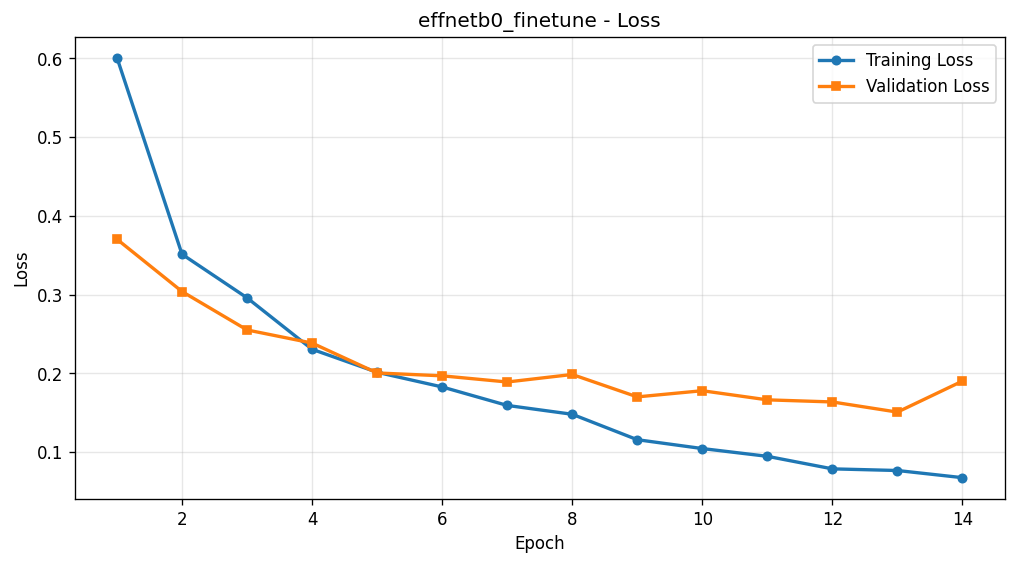

Loss:
  - loss [training dataset]: 0.068
  - loss [validation dataset]: 0.190

Accuracy:
  - accuracy [training dataset]: 97.55%
  - accuracy [validation dataset]: 92.67%


In [33]:
model_ft, history_ft, test_loss_ft, test_acc_ft, cm_ft, report_ft, roc_auc_dict_ft, macro_auc_ft, roc_raw_data_ft = train_test(
    cfg=cfg_effnet_ft,
    x_train_val_raw=x_train_val_raw,
    y_train_val_int=y_train_val_int,
    x_test_raw=x_test_raw,
    y_test_int=y_test_int,
    save_model=True
)

all_experiments["EfficientNetB0 FineTuning"] = {
    "macro_auc":    macro_auc_ft,
    "roc_raw_data": roc_raw_data_ft + ".npz"
}

In [34]:
del model_ft, history_ft, test_loss_ft, test_acc_ft, cm_ft, report_ft, roc_auc_dict_ft, macro_auc_ft, cfg_effnet_ft, roc_raw_data_ft
gc.collect()

39175

In [35]:
tf.keras.backend.clear_session()

# EfficientNetB0 Fine - Tuning + Data Augmentation Model

In [36]:
cfg_effnet_ft_aug = EXPERIMENTS["effnetb0_finetune_aug"]

## K-Fold(K = 5)

In [37]:
effnet_ft_aug_metrics, effnet_ft_aug_histories = kfold(
    x_raw=x_train_val_raw,
    y=y_train_val_int,
    cfg=cfg_effnet_ft_aug,
    K=K,
    BATCH_SIZE=BATCH_SIZE,
    LR=LR,
    EPOCHS=EPOCHS
)


=== effnetb0_finetune_aug / Fold 1/5 ===
Preprocessing for: effnet
Using preprocessing: effnet
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 178ms/step - accuracy: 0.7296 - loss: 0.6381 - val_accuracy: 0.7026 - val_loss: 0.6850
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.8505 - loss: 0.3661 - val_accuracy: 0.8065 - val_loss: 0.5104
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.8791 - loss: 0.3088 - val_accuracy: 0.8656 - val_loss: 0.3790
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.8995 - loss: 0.2533 - val_accuracy: 0.8595 - val_loss: 0.4043
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - accuracy: 0.9077 - loss: 0.2346 - val_accuracy: 0.8819 - val_loss: 0.3448
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.9184 - loss: 0.2037 - val_accuracy: 0.9063 - val_loss: 0.2998
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.9281 - loss: 0.1814 - val_accuracy: 0.9002 - val_loss: 0.2712
Epoch 8

In [38]:
effnet_aug_accuracy = [m["val_acc"] for m in effnet_ft_aug_metrics]
effnet_aug_losses = [m["val_loss"] for m in effnet_ft_aug_metrics]

print("Fold Accuracies:", effnet_aug_accuracy)
print("Mean Accuracy :", np.mean(effnet_aug_accuracy))
print("Std Accuracy  :", np.std(effnet_aug_accuracy))
print("Mean Loss     :", np.mean(effnet_aug_losses))
print("Std Loss      :", np.std(effnet_aug_losses))

Fold Accuracies: [0.9287168979644775, 0.9265305995941162, 0.9489796161651611, 0.9326530694961548, 0.9285714030265808]
Mean Accuracy : 0.9330903172492981
Std Accuracy  : 0.00818826334877057
Mean Loss     : 0.20650945007801055
Std Loss      : 0.04139760707651187


In [39]:
save_paths = get_save_paths(cfg_effnet_ft_aug["experiment_name"])

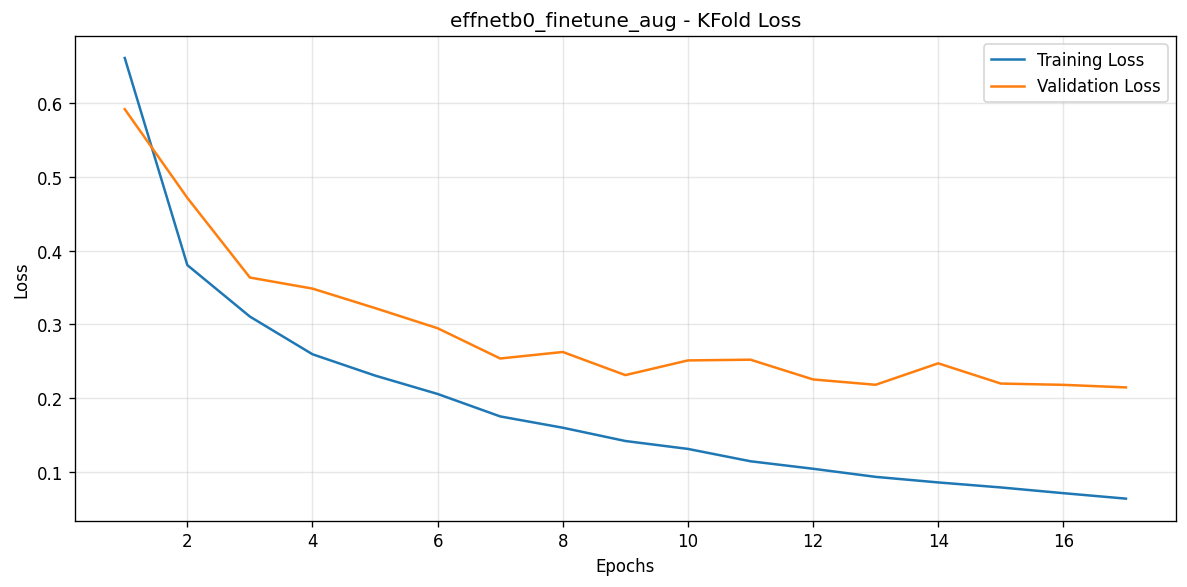

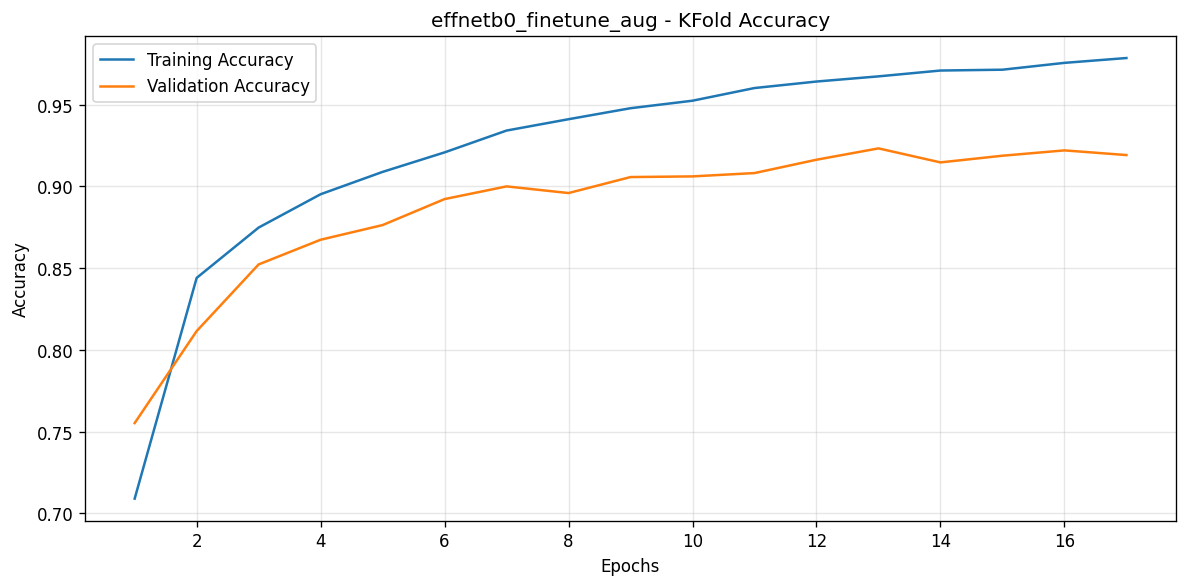

In [40]:
plot_kfold(
    effnet_ft_aug_histories,
    title_prefix=cfg_effnet_ft_aug["experiment_name"],
    save_paths=save_paths
)

In [41]:
with open(save_paths["kfold_metrics"], "w") as f:
    for row in effnet_ft_aug_metrics:
        f.write(f"Fold {row['fold']}: val_acc={row['val_acc']:.4f}, val_loss={row['val_loss']:.4f}\n")

    f.write("\n")
    f.write(f"Mean val_acc: {np.mean(effnet_aug_accuracy):.4f}\n")
    f.write(f"Std val_acc : {np.std(effnet_aug_accuracy):.4f}\n")
    f.write(f"Mean val_loss: {np.mean(effnet_aug_losses):.4f}\n")
    f.write(f"Std val_loss : {np.std(effnet_aug_losses):.4f}\n")

In [42]:
del effnet_ft_aug_metrics
del effnet_ft_aug_histories
gc.collect()

39818

In [43]:
tf.keras.backend.clear_session()

## Training + Evaluation

Preprocessing for: effnet
Using preprocessing: effnet
Preprocessing for: effnet
Using preprocessing: effnet
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 172ms/step - accuracy: 0.7189 - loss: 0.6650 - val_accuracy: 0.7984 - val_loss: 0.5125
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.8413 - loss: 0.3730 - val_accuracy: 0.8086 - val_loss: 0.4731
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - accuracy: 0.8679 - loss: 0.3202 - val_accuracy: 0.8269 - val_loss: 0.4018
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.8918 - loss: 0.2648 - val_accuracy: 0.8350 - val_loss: 0.3807
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.9117 - loss: 0.2284 - val_accuracy: 0.8391 - val_loss: 0.3459
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.9209 - loss: 0.2057 - val_accuracy: 0.8595 - val_loss: 0.3274
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - accuracy: 0.9316 - loss: 0.1796 - val_accuracy: 0.9063 - val_loss: 0

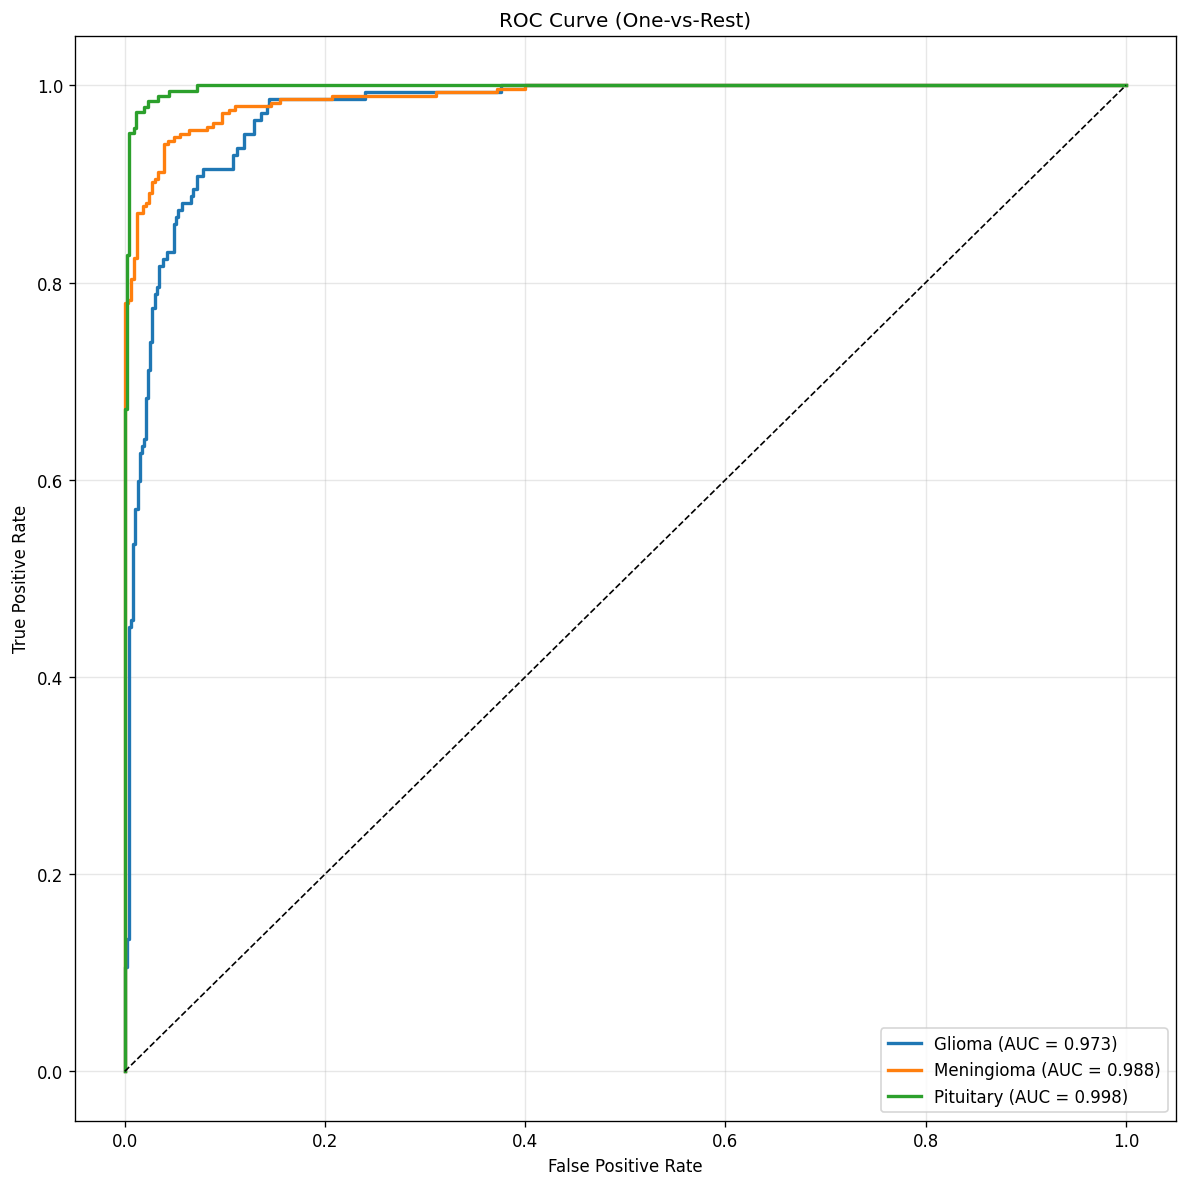


AUC per Class: 
Glioma: 0.9732
Meningioma: 0.9882
Pituitary: 0.9978
Macro AUC: 0.9864


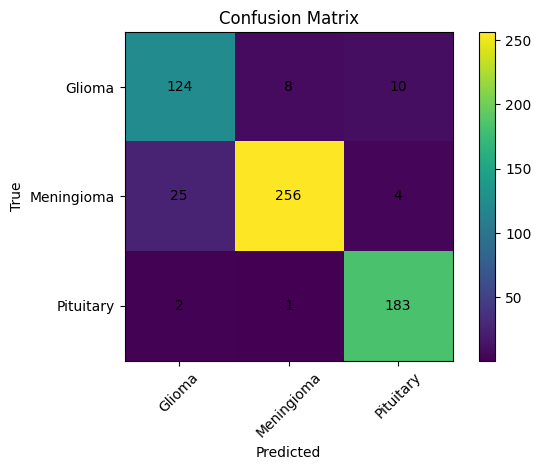

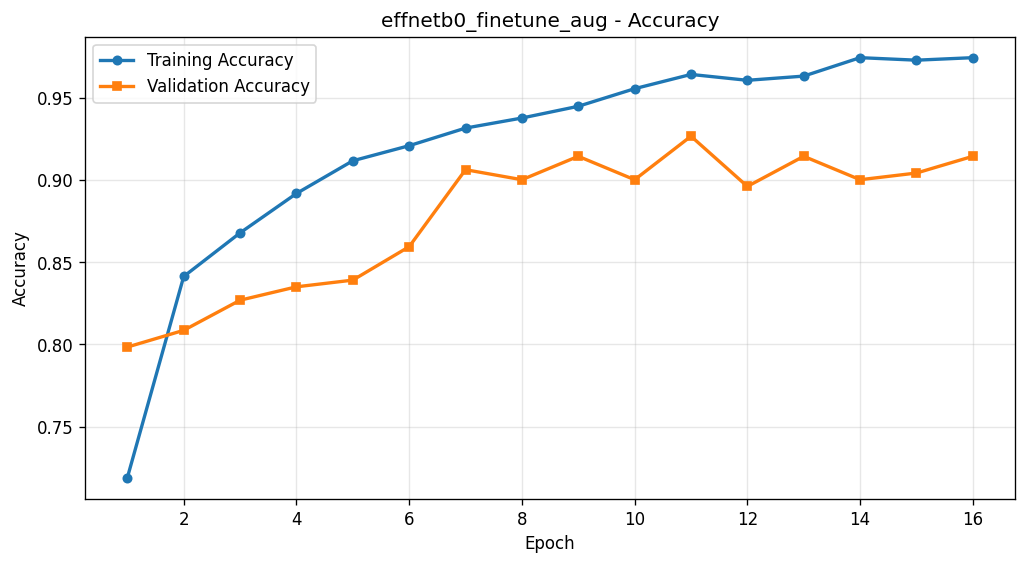

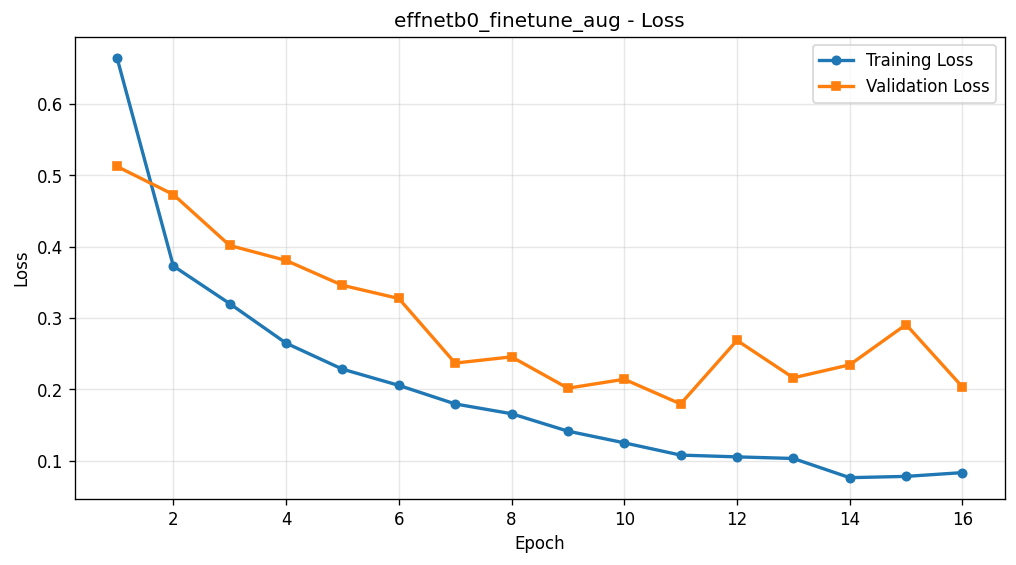

Loss:
  - loss [training dataset]: 0.083
  - loss [validation dataset]: 0.203

Accuracy:
  - accuracy [training dataset]: 97.45%
  - accuracy [validation dataset]: 91.45%


In [44]:
model_ft_aug, history_ft_aug, test_loss_ft_aug, test_acc_ft_aug, cm_ft_aug, report_ft_aug, roc_auc_dict_ft_aug, macro_auc_ft_aug, roc_raw_data_ft_aug = train_test(
    cfg=cfg_effnet_ft_aug,
    x_train_val_raw=x_train_val_raw,
    y_train_val_int=y_train_val_int,
    x_test_raw=x_test_raw,
    y_test_int=y_test_int,
    save_model=True
)

all_experiments["EfficientNetB0 FineTuning Aug"] = {
    "macro_auc":    macro_auc_ft_aug,
    "roc_raw_data": roc_raw_data_ft_aug + ".npz"
}

In [45]:
del model_ft_aug, history_ft_aug, test_loss_ft_aug, test_acc_ft_aug, cm_ft_aug, report_ft_aug, roc_auc_dict_ft_aug, macro_auc_ft_aug, cfg_effnet_ft_aug, roc_raw_data_ft_aug, x_train_val_raw, x_test_raw
gc.collect()

32607

In [46]:
tf.keras.backend.clear_session()

# EfficientNetB0 Fine - Tuning vs EfficientNetB0 Fine - Tuning Aug

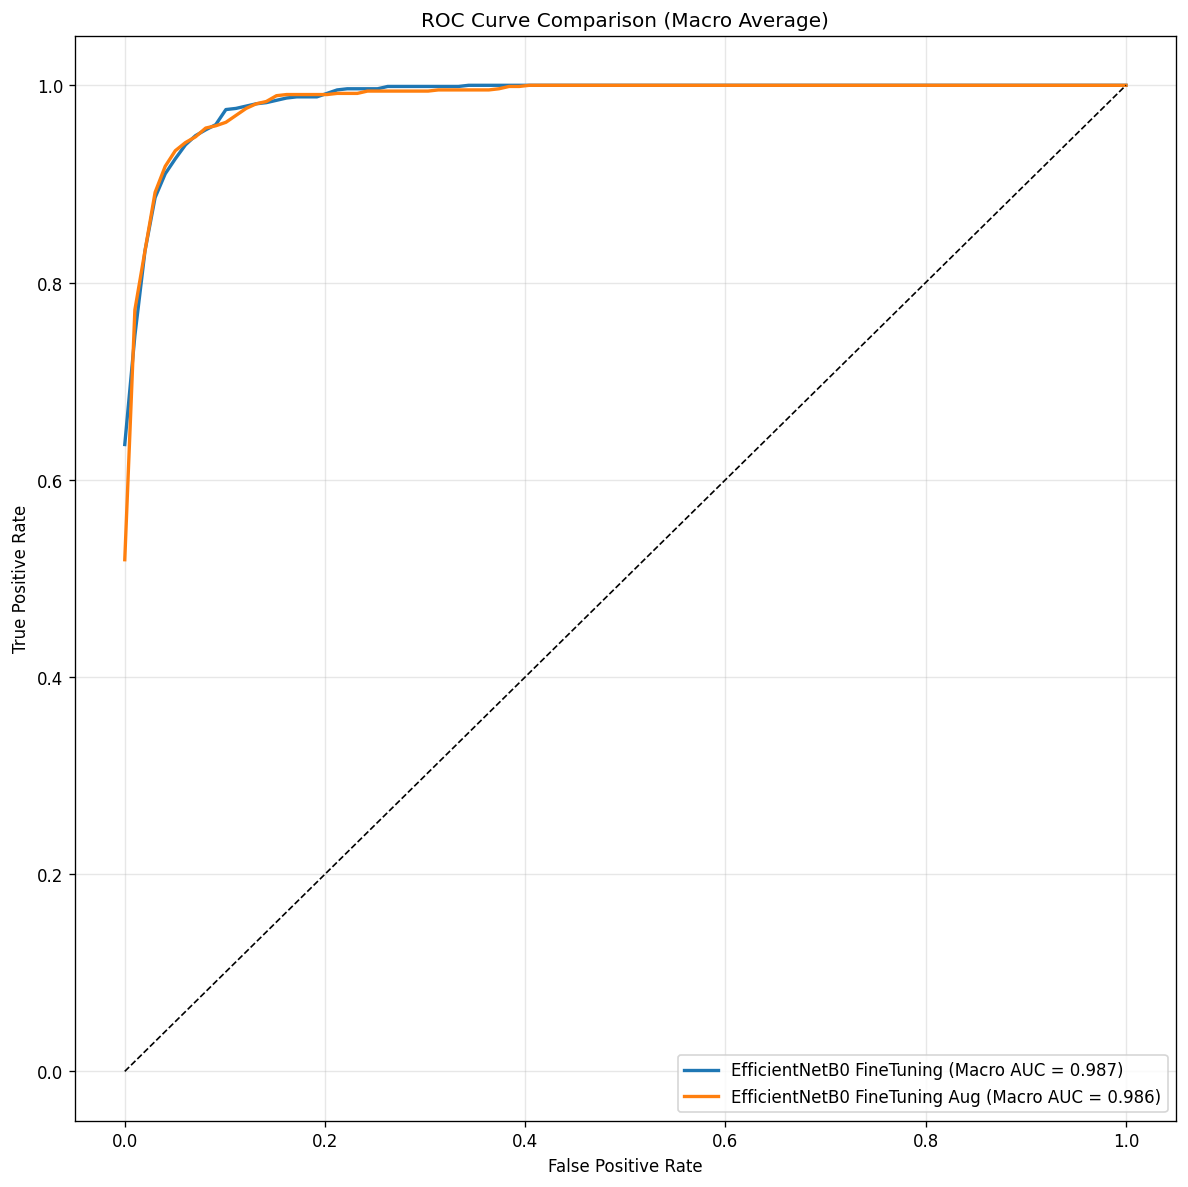

Best EffNetB0 Fine - Tuning experiment: EfficientNetB0 FineTuning (Macro AUC = 0.987)
Saved to: /content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/EfficientNetB0 fine-tuning Model/effnet_finetuning_experiments.pkl


In [47]:
plot_combined_roc(all_experiments, Class_Names, save_path=combined_roc_effnet_finetuning_path)

best_name, best_data = max(all_experiments.items(), key=lambda x: x[1]["macro_auc"])
print(f"Best EffNetB0 Fine - Tuning experiment: {best_name} (Macro AUC = {best_data['macro_auc']:.3f})")

with open(effnet_experiments_finetuning_path, "wb") as f:
    pickle.dump(all_experiments, f)

print(f"Saved to: {effnet_experiments_finetuning_path}")